In [3]:
import os
os.getcwd()


'C:\\Users\\saras\\Documents\\Y4\\HonsProject\\notebooks'

In [21]:
import pandas as pd
import json
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/names_results2.db")
df = pd.read_sql("SELECT * FROM names", engine)
df["full_countries_distribution"] = df["full_countries_distribution"].apply(json.loads)

df.head()


,name,full_countries_distribution,top_country,top_country_langs,top_country_prob,strong_top_country,agreement_score,n_models_used,name_script,name_latin,...,ethnicolr_prob,eth_distribution,langdetect_lang,langdetect_lang_name,langdetect_prob,country_lang_comp,hunspell_orig_known,hunspell_latin_known,pysc_orig_known,pysc_latin_known
0,A A Ron,"{'Afghanistan': None, 'Albania': None, 'Algeri...",United States,"[""en""]",0.615,0,NaN,2,Latin,A A Ron,...,0.670941,"{""African"": 0.0027, ""British"": 0.1046, ""EastAs...",hu,Hungarian,1.0000,0,0,0,0,0
1,A Abdiel,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Panama,"[""es""]",1.000,1,NaN,2,Latin,A Abdiel,...,0.436847,"{""African"": 0.4368, ""British"": 0.0349, ""EastAs...",de,German,0.7143,0,0,0,0,0
2,A Abera,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Ethiopia,"[""am""]",1.000,1,NaN,2,Latin,A Abera,...,0.163522,"{""African"": 0.1443, ""British"": 0.0711, ""EastAs...",hu,Hungarian,0.7143,0,0,0,0,0
3,A Al,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Bangladesh,"[""bn""]",0.414,0,NaN,2,Latin,A Al,...,0.452168,"{""African"": 0.0113, ""British"": 0.0479, ""EastAs...",hu,Hungarian,1.0000,0,0,0,0,0
4,A Alberto,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Costa Rica,"[""es""]",0.188,0,NaN,2,Latin,A Alberto,...,0.525892,"{""African"": 0.0104, ""British"": 0.0453, ""EastAs...",hu,Hungarian,1.0000,0,0,0,0,0


In [5]:
df2 = pd.read_sql("select count(*) from names where strong_top_country", engine)
df2.head()

,count(*)
0,339671


In [6]:
pd.read_sql("SELECT * FROM names WHERE name_script != 'Latin'", engine).head()

,name,full_countries_distribution,top_country,top_country_langs,top_country_prob,strong_top_country,agreement_score,n_models_used,name_script,name_latin,...,ethnicolr_prob,eth_distribution,langdetect_lang,langdetect_lang_name,langdetect_prob,country_lang_comp,hunspell_orig_known,hunspell_latin_known,pysc_orig_known,pysc_latin_known
0,[[,"{""Afghanistan"": null, ""Albania"": null, ""Algeri...",Morocco,"[""ar""]",0.881,1,NaN,0,Other,[[,...,NaN,"{""African"": null, ""British"": null, ""EastAsian""...",None,None,NaN,0,0,0,0,0
1,Άβα,"{""Afghanistan"": null, ""Albania"": null, ""Algeri...",Greece,"[""el""]",1.000,1,NaN,2,Greek,Ava,...,0.294456,"{""African"": 0.0184, ""British"": 0.0081, ""EastAs...",el,Modern Greek (1453-),1.0,1,0,1,0,0
2,Άγγελα,"{""Afghanistan"": null, ""Albania"": null, ""Algeri...",Cyprus,"[""el"", ""tr"", ""hy""]",1.000,1,NaN,2,Greek,Aggela,...,0.396450,"{""African"": 0.0783, ""British"": 0.188, ""EastAsi...",el,Modern Greek (1453-),1.0,1,0,0,0,0
3,Άγγελος,"{""Afghanistan"": null, ""Albania"": 0.008, ""Alger...",Greece,"[""el""]",0.912,1,NaN,2,Greek,Aggelos,...,0.262897,"{""African"": 0.0649, ""British"": 0.2361, ""EastAs...",el,Modern Greek (1453-),1.0,1,0,0,0,0
4,Άγης,"{""Afghanistan"": null, ""Albania"": null, ""Algeri...",Greece,"[""el""]",0.800,1,NaN,2,Greek,Agis,...,0.243387,"{""African"": 0.1312, ""British"": 0.0515, ""EastAs...",el,Modern Greek (1453-),1.0,1,0,0,0,0


In [7]:
pd.read_sql("SELECT * FROM names WHERE name_script = 'Other'", engine)

,name,full_countries_distribution,top_country,top_country_langs,top_country_prob,strong_top_country,agreement_score,n_models_used,name_script,name_latin,...,ethnicolr_prob,eth_distribution,langdetect_lang,langdetect_lang_name,langdetect_prob,country_lang_comp,hunspell_orig_known,hunspell_latin_known,pysc_orig_known,pysc_latin_known
0,[[,"{""Afghanistan"": null, ""Albania"": null, ""Algeri...",Morocco,"[""ar""]",0.881,1,None,0,Other,[[,...,None,"{""African"": null, ""British"": null, ""EastAsian""...",None,None,None,0,0,0,0,0


In [8]:
mask = df["name"].str.match(r"^[A-Za-z]?\s[A-Za-z]?$")
filtered = df[mask]
len(filtered)

0

In [9]:
strong = pd.read_sql("SELECT * FROM names WHERE country_lang_comp", engine)
len(strong)

137830

In [10]:
len(df)

727352

In [11]:
# Count number of parts when splitting by space
mask = df["name"].str.split().str.len() > 2

# Filter
multi_part_names = df[mask]
len(multi_part_names)

7501

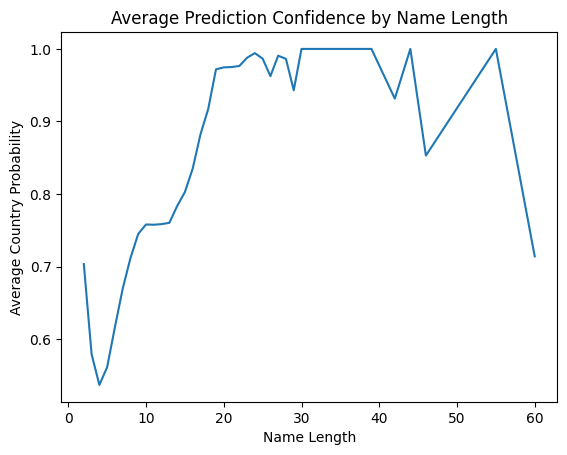

In [12]:
import matplotlib.pyplot as plt

df["name_length"] = df["name"].str.replace(" ", "", regex=False).str.len()
avg_conf = df.groupby("name_length")["top_country_prob"].mean()

avg_conf.plot()

plt.xlabel("Name Length")
plt.ylabel("Average Country Probability")
plt.title("Average Prediction Confidence by Name Length")

plt.show()

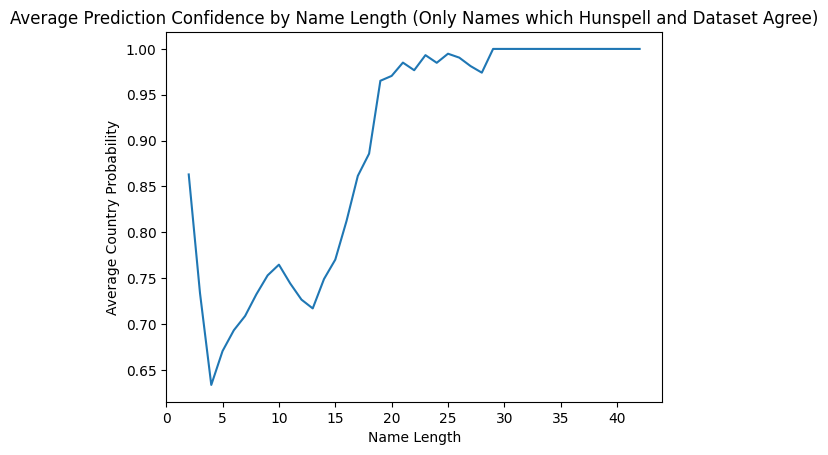

In [13]:
import matplotlib.pyplot as plt

strong["name_length"] = strong["name"].str.replace(" ", "", regex=False).str.len()
avg_conf = strong.groupby("name_length")["top_country_prob"].mean()

avg_conf.plot()

plt.xlabel("Name Length")
plt.ylabel("Average Country Probability")
plt.title("Average Prediction Confidence by Name Length (Only Names which Hunspell and Dataset Agree)")

plt.show()

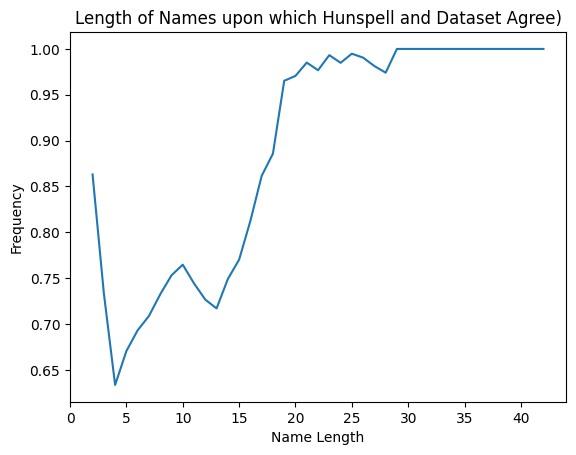

In [14]:
import matplotlib.pyplot as plt

strong["name_length"] = strong["name"].str.replace(" ", "", regex=False).str.len()
avg_conf = strong.groupby("name_length")["top_country_prob"].mean()

avg_conf.plot()

plt.xlabel("Name Length")
plt.ylabel("Frequency")
plt.title("Length of Names upon which Hunspell and Dataset Agree)")

plt.show()

In [22]:
pd.read_sql("select count(*) from names where hunspell_orig_known", engine)

,count(*)
0,18834


In [23]:
pd.read_sql("select count(*) from names where hunspell_latin_known", engine)

,count(*)
0,27999


In [24]:
pd.read_sql("select count(*) from names where hunspell_orig_known and hunspell_latin_known", engine)

,count(*)
0,18834


In [28]:
df["hunspell_flag"] = ~df["hunspell_orig_known"]
df["hunspell_latin_flag"] = ~df["hunspell_latin_known"]
flag_freq_lang = (
    df[df["hunspell_flag"]]
    ["langdetect_lang_name"]
    .value_counts()
)

flag_freq_lang.head(20).plot.bar()

plt.title("Hunspell Flag Frequency by Detected Language")
plt.ylabel("Number of Flagged Names")
plt.xlabel("Language")
plt.show()

KeyError: "None of [Index([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,\n       ...\n       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],\n      dtype='int64', length=727352)] are in the [columns]"